<a href="https://colab.research.google.com/github/Rohith-Datta/CC-ML-task1-Submission/blob/main/failsafe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
from google.colab import files
files.upload() # Select your kaggle.json file here

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rohithdattabandaru","key":"6c6b93dda2fea6553abbcfff794bdec4"}'}

In [5]:
# Create the hidden folder
!mkdir -p ~/.kaggle
# Move the key there
!cp kaggle.json ~/.kaggle/
# Set permissions so only you can read it (security best practice)
!chmod 600 ~/.kaggle/kaggle.json


In [6]:
# Change directory to your Drive folder
%cd /content/drive/My\ Drive/Failsafe-ML

# Download the dataset
!kaggle datasets download -d uciml/student-alcohol-consumption

# Unzip the file
!unzip student-alcohol-consumption.zip

/content/drive/My Drive/Failsafe-ML
Dataset URL: https://www.kaggle.com/datasets/uciml/student-alcohol-consumption
License(s): CC0-1.0
student-alcohol-consumption.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  student-alcohol-consumption.zip
replace student-mat.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: student-mat.csv         
replace student-merge.R? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: student-merge.R         
replace student-por.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: student-por.csv         


In [7]:
import pandas as pd


df = pd.read_csv('student-mat.csv')


df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [9]:
# SANITY CHECK:
print("Dataset Shape:", df.shape)
print("\nMissing Values per column:\n", df.isnull().sum().max())
print("\nData Types:\n", df.dtypes.value_counts())

# PREVENTING DATA LEAKAGE:
df['Risk'] = df['G3'].apply(lambda x: 1 if x < 10 else 0)
df_preclean = df.drop(columns=['G1', 'G2', 'G3'])

# NEW TARGET VARIABLE ("Risk") overview:
print("\nTarget Variable Distribution:")
print(df_preclean['Risk'].value_counts(normalize=True) * 100)


Dataset Shape: (395, 34)

Missing Values per column:
 0

Data Types:
 object    17
int64     17
Name: count, dtype: int64

Target Variable Distribution:
Risk
0    67.088608
1    32.911392
Name: proportion, dtype: float64


In [10]:
#ENCODING:


print("Columns before encoding:", df_preclean.shape[1])
demographic_cols = [
    'school', 'sex', 'age', 'address', 'famsize',
     'reason', 'guardian', 'Medu','Fedu','Mjob','Fjob','Pstatus','schoolsup','famsup','paid','nursery','famrel'
]
df_clean = df_preclean.drop(columns=demographic_cols)
# pd.get_dummies automatically finds all 'object' (text) columns and One-Hot Encodes them.
# drop_first=True prevents the "Dummy Variable Trap" (e.g., if Sex_M is 0, we know they are F, so we don't need a Sex_F column)
# dtype=int ensures the output is 1s and 0s instead of True/False
df_encoded = pd.get_dummies(df_clean, drop_first=True, dtype=int)

# Let's see how many columns we have AFTER encoding
print("Columns after encoding:", df_encoded.shape[1])

# Look at the new column names
print("\nNew columns:\n", df_encoded.columns.tolist())

# Look at the first 3 rows to verify it worked
df_encoded.head(3)

Columns before encoding: 31
Columns after encoding: 14

New columns:
 ['traveltime', 'studytime', 'failures', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'Risk', 'activities_yes', 'higher_yes', 'internet_yes', 'romantic_yes']


,traveltime,studytime,failures,freetime,goout,Dalc,Walc,health,absences,Risk,activities_yes,higher_yes,internet_yes,romantic_yes
0,2,2,0,3,4,1,1,3,6,1,0,1,0,0
1,1,2,0,3,3,1,1,3,4,1,0,1,1,0
2,1,2,3,3,2,2,3,3,10,0,0,1,1,0


In [11]:
# --- STEP 5: TRAIN/TEST SPLIT & MODEL TRAINING ---

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Separate Features (X) and Target (y)
# We drop the 'Risk' column to create X, and keep ONLY 'Risk' for y
X = df_encoded.drop('Risk', axis=1)
y = df_encoded['Risk']

# 2. Split the data (80% for training, 20% for hidden testing)
# random_state ensures we get the exact same split every time we run the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {X_train.shape[0]} students...")
print(f"Testing on {X_test.shape[0]} students...\n")

# 3. Initialize the XGBoost Classifier
# We start with basic parameters.
model = XGBClassifier(
    n_estimators=100,      # Number of decision trees
    learning_rate=0.1,     # Step size for learning
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'  # The probability loss function XGBoost optimizes
)

# 4. Train the Model
model.fit(X_train, y_train)
print("Model Training Complete!\n")

# 5. Make Predictions on the hidden test set
y_pred = model.predict(X_test)

# 6. Evaluate the results
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy * 100:.2f}%\n")

print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

Training on 316 students...
Testing on 79 students...

Model Training Complete!

Overall Accuracy: 70.89%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.90      0.80        52
           1       0.64      0.33      0.44        27

    accuracy                           0.71        79
   macro avg       0.68      0.62      0.62        79
weighted avg       0.70      0.71      0.68        79



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:42:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Generating SHAP Summary Plot...


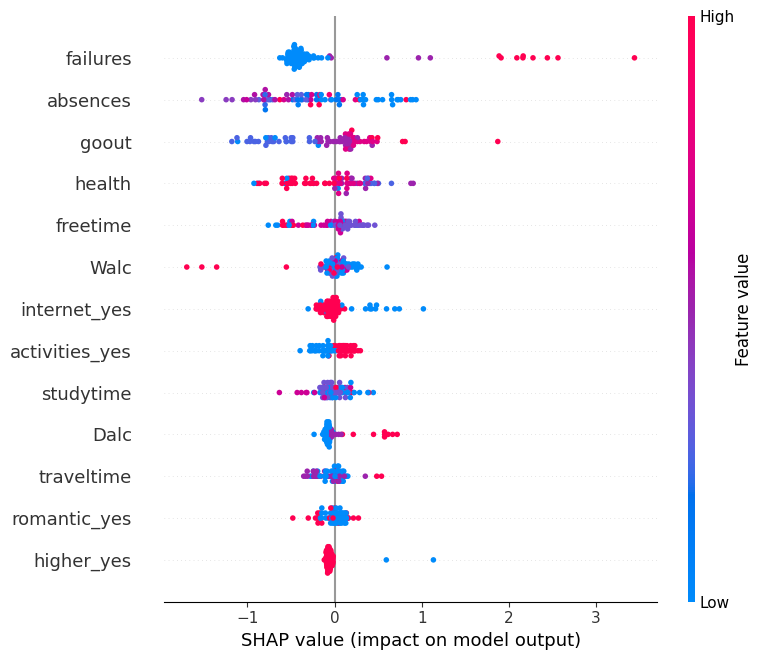

In [12]:
# --- STEP 6: SHAP EXPLAINABILITY ---

# 1. Install SHAP (Colab needs to download it)
!pip install -q shap

import shap
import matplotlib.pyplot as plt

# 2. Initialize the SHAP Tree Explainer with your trained XGBoost model
explainer = shap.TreeExplainer(model)

# 3. Calculate SHAP values for the test set
# This might take a few seconds as it calculates the game-theory math for every feature
shap_values = explainer(X_test)

# 4. Generate the Global Summary Plot
print("Generating SHAP Summary Plot...")
shap.summary_plot(shap_values, X_test)